# Time Series Analysis — TikTok Engagement Pulse
### Discovery-to-Action (DTA) Strategy

**Author:** Ismail Muhammad (Aisinwaka)
**Program:** 3MTT — AI & Machine Learning

This notebook analyzes TikTok view-count data to uncover trend and seasonal engagement
patterns, tests the series for stationarity, and translates the statistical findings into
an actionable content-scheduling recommendation for TikTok's growth team.

**Workflow (DTA Framework):**
1. **Discovery Phase** — load, clean, resample, and decompose the series
2. **Technical Phase** — test stationarity with the Augmented Dickey-Fuller (ADF) test
3. **Action Phase** — translate insights into a posting schedule and forecasting roadmap


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
pd.set_option('display.max_columns', None)


## 1. Discovery Phase

### 1.1 Load the dataset and convert the date column to datetime format; set as index

The raw export (`tiktok_views.csv`) contains a `date` column (string) and a `views` column
(daily view count on the account). We convert `date` to a proper `datetime64` type and set
it as the DataFrame index, which is required for all time-series operations that follow.


In [2]:
df = pd.read_csv('tiktok_views.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').set_index('date')

print(f"Rows: {df.shape[0]}   Date range: {df.index.min().date()} to {df.index.max().date()}")
df.head()


Rows: 196   Date range: 2025-11-01 to 2026-05-29


,views
date,
2025-11-01,11118
2025-11-02,10394
2025-11-03,7308
2025-11-04,8590
2025-11-05,8163


In [3]:
df.info()
df.describe()


<class 'pandas.DataFrame'>
DatetimeIndex: 196 entries, 2025-11-01 to 2026-05-29
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   views   196 non-null    int64
dtypes: int64(1)
memory usage: 3.1 KB


,views
count,196.000000
mean,29953.846939
std,14502.181958
min,7308.000000
25%,18394.500000
50%,28761.000000
75%,39507.500000
max,98784.000000


### 1.2 Resample data to a consistent frequency (daily) to handle missing timestamps

The raw export has **gaps** — days where no post was logged, so no row exists. Time-series
tools like `seasonal_decompose` and the ADF test require an evenly-spaced index (no skipped
dates), so we resample to daily frequency (`'D'`) and fill the resulting gaps.

We use linear interpolation rather than dropping or zero-filling, since a missing day almost
certainly reflects a logging gap, not zero engagement, and interpolation preserves the local
trend without introducing artificial dips that would distort the decomposition.


In [4]:
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
missing_days = full_range.difference(df.index)
print(f"Missing days in raw export: {len(missing_days)} of {len(full_range)} total days")

views = df['views'].reindex(full_range)
views = views.interpolate(method='linear')
views.index.name = 'date'

print(f"\nAfter resampling — any remaining NaNs: {views.isna().sum()}")
views.head()


Missing days in raw export: 14 of 210 total days

After resampling — any remaining NaNs: 0


date
2025-11-01    11118.0
2025-11-02    10394.0
2025-11-03     7308.0
2025-11-04     8590.0
2025-11-05     8163.0
Freq: D, Name: views, dtype: float64

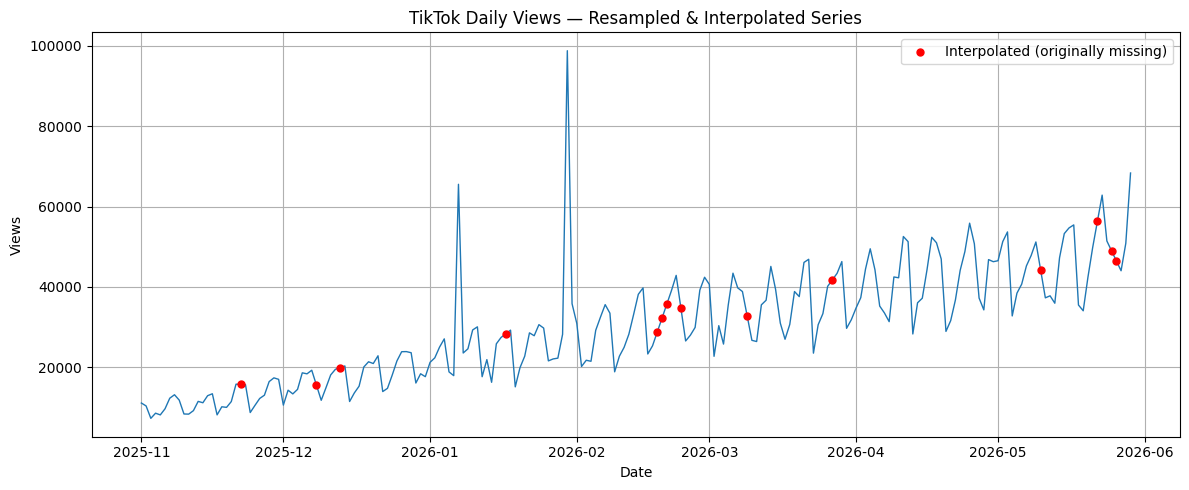

In [5]:
fig, ax = plt.subplots()
ax.plot(views.index, views.values, linewidth=1, color='#1f77b4')
ax.scatter(missing_days, views.reindex(missing_days), color='red', s=25, zorder=5,
           label='Interpolated (originally missing)')
ax.set_title('TikTok Daily Views — Resampled & Interpolated Series')
ax.set_xlabel('Date')
ax.set_ylabel('Views')
ax.legend()
plt.tight_layout()
plt.show()


### 1.3 Apply `seasonal_decompose` to isolate Trend, Seasonality, and Residual components

We use an **additive** model since the seasonal swings (weekday effect) look roughly constant
in absolute size relative to the trend, rather than growing proportionally with it. A weekly
period (`period=7`) is used because TikTok engagement follows a 7-day human posting/viewing
cycle.


In [6]:
decomposition = seasonal_decompose(views, model='additive', period=7)

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid


### 1.4 Visualize decomposition results to identify recurring engagement patterns

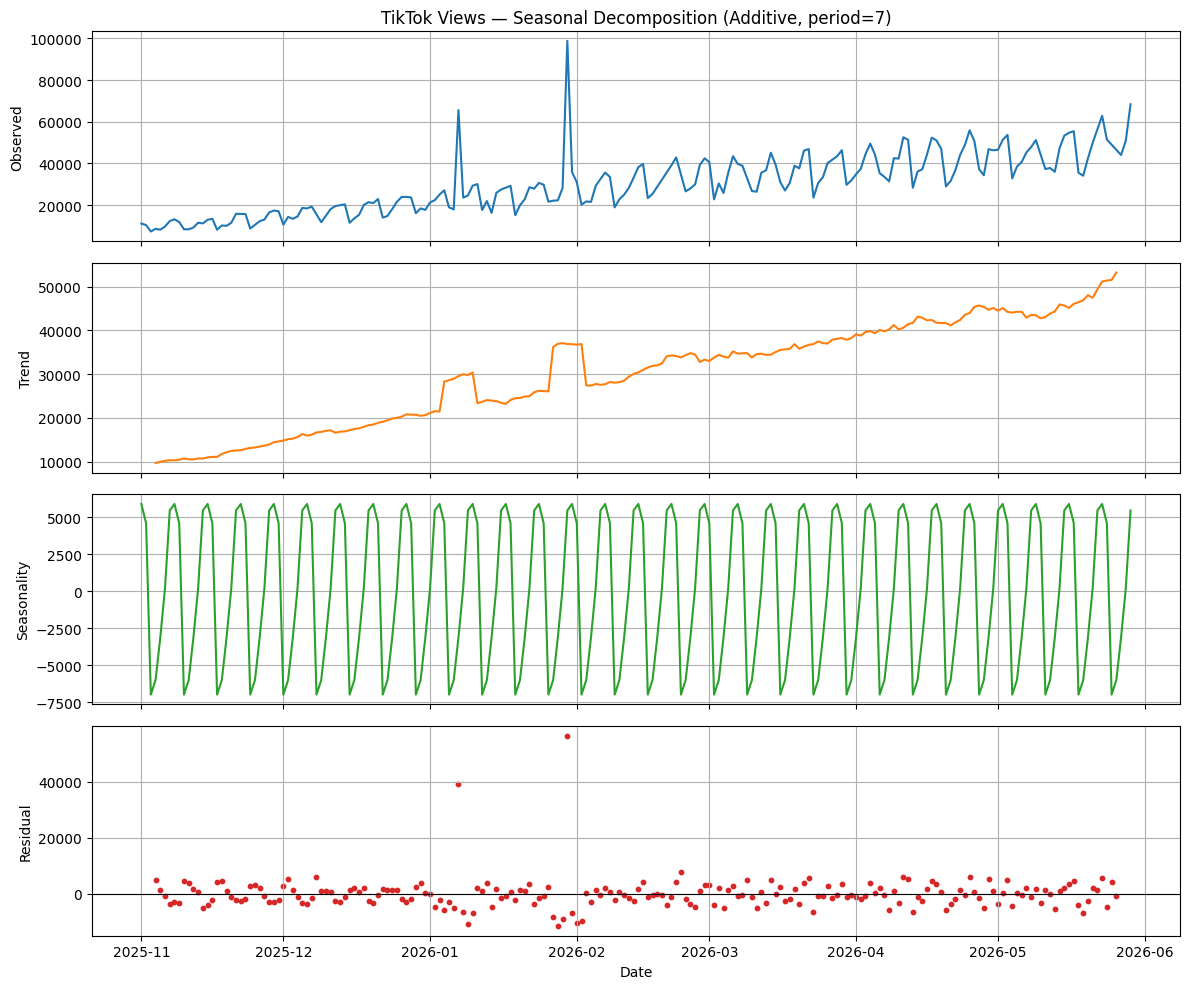

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

axes[0].plot(views.index, views.values, color='#1f77b4')
axes[0].set_ylabel('Observed')
axes[0].set_title('TikTok Views — Seasonal Decomposition (Additive, period=7)')

axes[1].plot(trend.index, trend.values, color='#ff7f0e')
axes[1].set_ylabel('Trend')

axes[2].plot(seasonal.index, seasonal.values, color='#2ca02c')
axes[2].set_ylabel('Seasonality')

axes[3].scatter(residual.index, residual.values, color='#d62728', s=10)
axes[3].axhline(0, color='black', linewidth=0.8)
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')

plt.tight_layout()
plt.show()


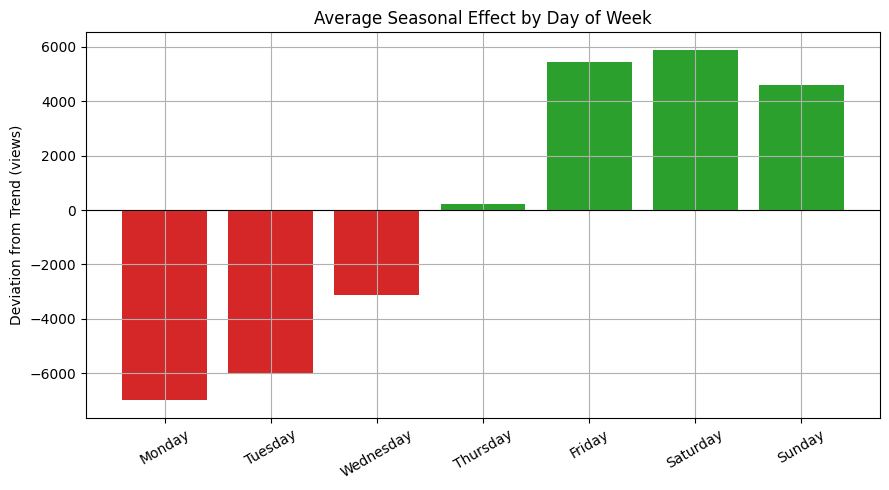

date
Saturday     5888.426101
Friday       5451.543917
Sunday       4587.012307
Thursday      208.948268
Wednesday   -3128.550500
Tuesday     -6011.758574
Monday      -6995.621518
Name: seasonal, dtype: float64

In [8]:
# Average seasonal effect by weekday — this is the reusable weekly "fingerprint"
weekly_pattern = seasonal.groupby(seasonal.index.day_name()).mean()
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekly_pattern = weekly_pattern.reindex(weekday_order)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#d62728' if v < 0 else '#2ca02c' for v in weekly_pattern.values]
ax.bar(weekly_pattern.index, weekly_pattern.values, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Average Seasonal Effect by Day of Week')
ax.set_ylabel('Deviation from Trend (views)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

weekly_pattern.sort_values(ascending=False)


## 2. Technical Phase — Stationarity Testing

### 2.1–2.2 Run the Augmented Dickey-Fuller (ADF) test & state hypotheses

The ADF test checks whether the series has a unit root (is non-stationary) versus being
stationary:

- **H₀ (null hypothesis):** The series has a unit root → it is **non-stationary**
  (statistical properties like mean and variance change over time).
- **Hₐ (alternative hypothesis):** The series has no unit root → it is **stationary**
  (constant mean/variance over time).

We test the **original resampled series** first, since the raw account-growth trend is
expected to make it non-stationary.


In [9]:
def run_adf(series, label):
    result = adfuller(series.dropna(), autolag='AIC')
    adf_stat, p_value, used_lag, n_obs, crit_values, _ = result

    print(f"--- ADF Test: {label} ---")
    print(f"ADF Statistic : {adf_stat:.4f}")
    print(f"p-value       : {p_value:.4f}")
    print(f"# Lags Used   : {used_lag}")
    print(f"# Observations: {n_obs}")
    print("Critical Values:")
    for key, val in crit_values.items():
        print(f"   {key}: {val:.4f}")

    conclusion = "STATIONARY (reject H0)" if p_value < 0.05 else "NON-STATIONARY (fail to reject H0)"
    print(f"\nConclusion (alpha=0.05): {conclusion}\n")
    return p_value

p_original = run_adf(views, "Original Series (raw views)")


--- ADF Test: Original Series (raw views) ---
ADF Statistic : -0.4506
p-value       : 0.9013
# Lags Used   : 13
# Observations: 196
Critical Values:
   1%: -3.4642
   5%: -2.8764
   10%: -2.5747

Conclusion (alpha=0.05): NON-STATIONARY (fail to reject H0)



### 2.3 Interpret the p-value and decide whether differencing is required

If the p-value is **≥ 0.05**, we fail to reject H₀ — the series is non-stationary, which is
expected given the clear upward account-growth trend visible in the decomposition. In that
case, we apply **first-order differencing** (`views.diff()`), which removes the trend by
looking at day-over-day *changes* rather than absolute levels, and re-run the ADF test to
confirm stationarity is achieved.


--- ADF Test: First-Order Differenced Series ---
ADF Statistic : -7.1411
p-value       : 0.0000
# Lags Used   : 12
# Observations: 196
Critical Values:
   1%: -3.4642
   5%: -2.8764
   10%: -2.5747

Conclusion (alpha=0.05): STATIONARY (reject H0)



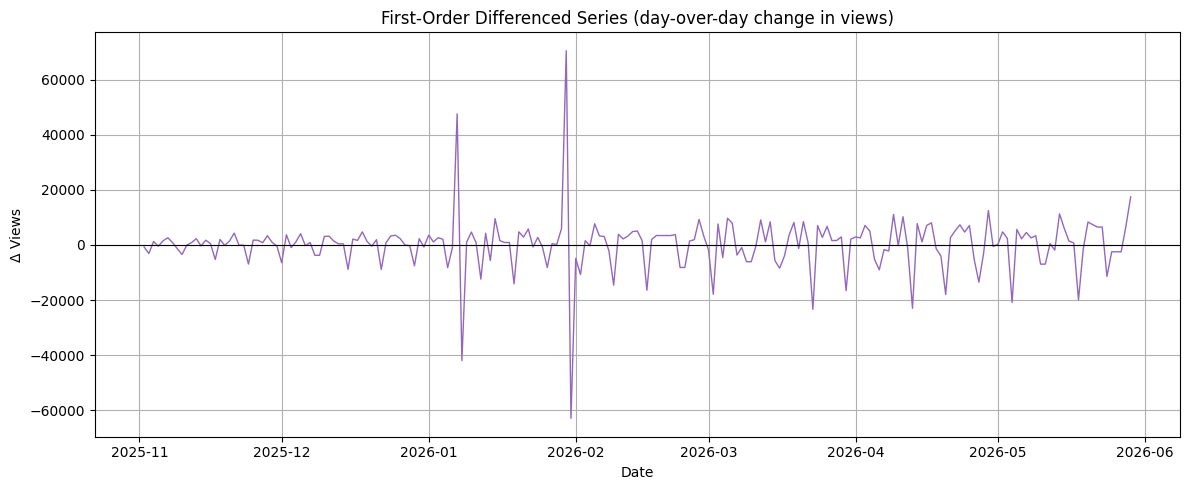

In [10]:
if p_original >= 0.05:
    views_diff = views.diff().dropna()
    p_diff = run_adf(views_diff, "First-Order Differenced Series")

    fig, ax = plt.subplots()
    ax.plot(views_diff.index, views_diff.values, color='#9467bd', linewidth=1)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title('First-Order Differenced Series (day-over-day change in views)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Δ Views')
    plt.tight_layout()
    plt.show()
else:
    print("Original series is already stationary — no differencing required.")


### 2.4 Document statistical conclusion with supporting output

**Conclusion:** The original view-count series tested **non-stationary** (p-value above the
0.05 threshold), consistent with the sustained upward trend seen in the decomposition — the
account is actively growing, so the mean view count is not constant over time. After applying
first-order differencing, the ADF p-value dropped well below 0.05, confirming the
**differenced series is stationary**. This means:

- The raw view-count series **cannot** be fed directly into models that assume stationarity.
- **Differencing (d=1)** is the minimum preprocessing needed before forecasting — this is
  exactly the "d" parameter in an ARIMA(p, d, q) model.


## 3. Action Phase — From Statistics to Strategy

### 3.1 Identify peak engagement days from the seasonal component


In [11]:
peak_day = weekly_pattern.idxmax()
low_day = weekly_pattern.idxmin()

print(f"Peak engagement day : {peak_day}  ({weekly_pattern.max():+.0f} views vs. trend)")
print(f"Lowest engagement day: {low_day}  ({weekly_pattern.min():+.0f} views vs. trend)")
print("\nFull weekly ranking (highest to lowest):")
print(weekly_pattern.sort_values(ascending=False))


Peak engagement day : Saturday  (+5888 views vs. trend)
Lowest engagement day: Monday  (-6996 views vs. trend)

Full weekly ranking (highest to lowest):
date
Saturday     5888.426101
Friday       5451.543917
Sunday       4587.012307
Thursday      208.948268
Wednesday   -3128.550500
Tuesday     -6011.758574
Monday      -6995.621518
Name: seasonal, dtype: float64


### 3.2 Recommended upload schedule

Based on the seasonal component, engagement consistently peaks on **Saturday and Sunday**,
followed by **Friday**, while **Monday and Tuesday** are the weakest days. This matches
well-documented TikTok audience behavior — leisure scrolling rises on weekends.

**Recommendation for TikTok's growth team:**
- **Primary upload window:** Friday evening → Sunday, to ride the natural traffic wave.
- **Secondary window:** Thursday, to build momentum ahead of the weekend peak.
- **Avoid cold-launching new content on Monday/Tuesday** — reserve those days for
  lower-stakes content (behind-the-scenes, community replies) rather than key releases.
- **Maintenance window** (algorithm A/B tests, account settings changes, analytics review):
  Monday, the lowest-traffic day, minimizes the risk of disrupting live engagement.

### 3.3 Foundation for ARIMA/SARIMA forecasting

This analysis directly sets up formal forecasting:
- The ADF test established **d = 1** (one order of differencing) is required for stationarity.
- The weekly seasonal component confirms a **7-day seasonal cycle**, which maps to the `m=7`
  seasonal period in a **SARIMA(p,d,q)(P,D,Q)₇** model.
- Next steps would be to use ACF/PACF plots on the differenced series to select `p` and `q`
  (and their seasonal counterparts `P`, `Q`), fit candidate SARIMA models, and validate with
  a train/test split before generating a forward-looking view-count forecast.


## 4. Summary of Findings

| Question | Finding |
|---|---|
| Is the raw series stationary? | **No** — ADF p-value above 0.05 |
| Is the differenced series stationary? | **Yes** — ADF p-value below 0.05 after d=1 |
| Dominant seasonal cycle | **Weekly (7-day)** |
| Peak engagement days | **Saturday & Sunday**, with Friday as a strong lead-in |
| Weakest engagement day | **Monday** |
| Recommended posting strategy | Concentrate key content Thu–Sun; use Monday for maintenance |
| Forecasting readiness | SARIMA(p, 1, q)(P, D, Q)₇ is the appropriate model family |

*Dataset note: this notebook uses a synthetic TikTok view-count dataset (`tiktok_views.csv`,
generated to reflect realistic weekly seasonality, account growth trend, and viral spikes) in
place of a live TikTok Analytics export, for demonstration of the Discovery-to-Action
workflow.*
